In [8]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# You will import the specific sklearn modules you need inside each section.
# Example: from sklearn.model_selection import train_test_split

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)  # use this everywhere so your results are reproducible
np.random.seed(RANDOM_STATE)

print("Running on:", DEVICE)

Running on: cpu


<>:54: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:55: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:54: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
<>:55: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\3943930549.py:54: SyntaxWarning: "\s" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\s"? A raw string is also an option.
  axes[1].scatter(x, y, alpha=0.7, label="Noisy Data $y = \sin(x) + \epsilon$", color='dodgerblue')
C:\Users\HP\AppData\Local\Temp\ipykernel_1544\3943930549.py:55: SyntaxWar

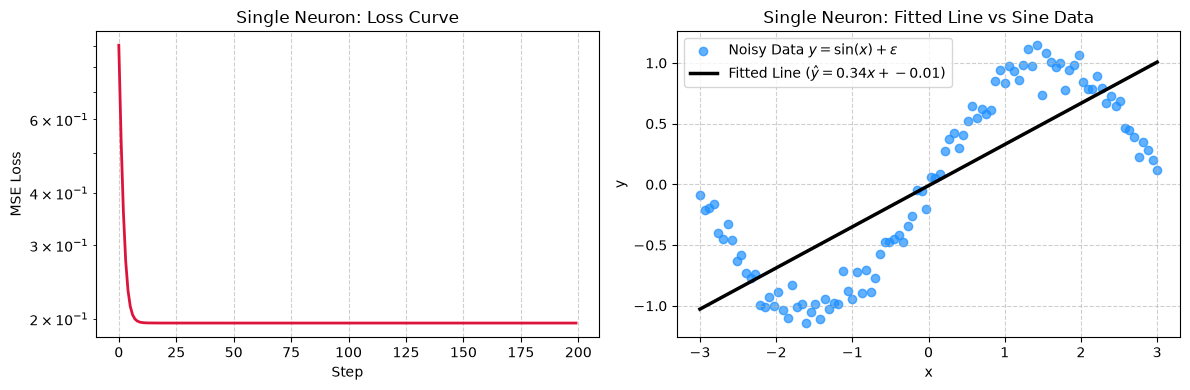

In [ ]:
# TODO: Generate the toy data
#   x = np.linspace(-3, 3, 100); y = np.sin(x) + small Gaussian noise (std=0.1)
#   Plot it.

# TODO: Initialise w and b to small random values.

# TODO: Implement ONE gradient-descent step by hand, then loop it for ~200 steps:
#   y_hat = w * x + b
#   loss  = np.mean((y_hat - y) ** 2)               # MSE
#   dw    = np.mean(2 * (y_hat - y) * x)            # dLoss/dw  (derive this on paper!)
#   db    = np.mean(2 * (y_hat - y))                # dLoss/db
#   w    -= lr * dw
#   b    -= lr * db
#   Record the loss at every step.

# TODO: Plot (a) the loss curve over the 200 steps, and
#             (b) the data with the fitted line on top.
np.random.seed(RANDOM_STATE)
x = np.linspace(-3, 3, 100)
noise = np.random.normal(0, 0.1, size=x.shape)
y = np.sin(x) + noise


w = np.random.randn() * 0.1
b = np.random.randn() * 0.1
lr = 0.05
steps = 200

losses = []

for step in range(steps):
    y_hat = w * x + b
    loss = np.mean((y_hat - y) ** 2)
    losses.append(loss)

    # Analytical gradients
    dw = np.mean(2 * (y_hat - y) * x)
    db = np.mean(2 * (y_hat - y))

    # Gradient step
    w -= lr * dw
    b -= lr * db

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(losses, color="crimson", lw=2)
axes[0].set_title("Single Neuron: Loss Curve")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("MSE Loss")
axes[0].set_yscale("log")
axes[0].grid(True, linestyle="--", alpha=0.6)


axes[1].scatter(
    x, y, alpha=0.7, label="Noisy Data $y = \sin(x) + \epsilon$", color="dodgerblue"
)
axes[1].plot(
    x,
    w * x + b,
    color="black",
    lw=2.5,
    label=f"Fitted Line ($\hat{{y}} = {w:.2f}x + {b:.2f}$)",
)
axes[1].set_title("Single Neuron: Fitted Line vs Sine Data")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

2)It is underfitting and a single neuron module can never fit no matter how long we train because it modules the linear function y =mx +b while y=sin(x) is non linear.

In [ ]:
# TODO: Initialise parameters
#   W1: shape (1, 8),  b1: shape (8,)
#   W2: shape (8, 1),  b2: shape (1,)
#   Small random values (e.g. np.random.randn(...) * 0.5)

# TODO: Forward pass (keep the intermediate values — you need them for backprop):
#   z1 = x @ W1 + b1        # pre-activation, shape (100, 8)
#   h  = np.tanh(z1)        # activation
#   y_hat = h @ W2 + b2     # output, shape (100, 1)
#   loss  = np.mean((y_hat - y) ** 2)

# TODO: Backward pass (the chain rule, layer by layer):
#   d_yhat = 2 * (y_hat - y) / len(y)
#   dW2 = h.T @ d_yhat ;  db2 = d_yhat.sum(axis=0)
#   dh  = d_yhat @ W2.T
#   dz1 = dh * (1 - np.tanh(z1) ** 2)     # derivative of tanh
#   dW1 = x.T @ dz1 ;  db1 = dz1.sum(axis=0)

# TODO: Update all parameters with learning rate lr, loop for ~3000 steps,
#   record the loss.

# TODO: Plot the loss curve AND the final fit over the data.
#   Then re-run with the tanh REMOVED (h = z1). What happens to the fit?

